# Assignment – Variable Density Non-Cartesian MRI Sampling (mri-nufft)

In this notebook I try to simulate different non-Cartesian sampling schemes in k-space and reconstruct MR images using the `mri-nufft` library. The main idea is to play with **variable density sampling (VDS)** in k-space, generate trajectories that follow these densities, and see how this affects the reconstruction quality.

**Goal (my understanding):**
- Start from a realistic BrainWeb MRI slice.
- Build several **sampling densities** in k-space:
  1. Uniform density.
  2. Variable density: central 25% of k-space at constant density + polynomial decay (decay = 2).
  3. Energy-based density: proportional to the k-space energy of the image.
- From these densities, generate sampling patterns with **32 shots** and **512 samples per shot**, then reconstruct the image using NUFFT (forward + adjoint).


## 1. Environment and packages

Here I load the main libraries I will use: `numpy` and `matplotlib` for numerics/plots, `brainweb_dl` to get an MR image, and `mri-nufft` (with `finufft` backend) for non-Cartesian NUFFT operators. I also print Python / NumPy versions to keep track of the environment.


In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import mrinufft
import brainweb_dl
import finufft
from brainweb_dl import get_mri

print("Python:", sys.version.splitlines()[0])
print("numpy:", np.__version__)


Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
numpy: 1.26.4


## 1.Load and Display the MRI Image

Before playing with k-space and trajectories, I first load a **T1-weighted BrainWeb volume** using `brainweb_dl.get_mri`. The data is 3D (all slices of the brain), so I pick one 2D slice to work with.

I also flip the volume so that the orientation looks more anatomically correct when I plot it. This is only for visualization – all information is preserved. The resulting 2D image will be my **“ground truth”** in the image domain for all the sampling and reconstruction experiments later.


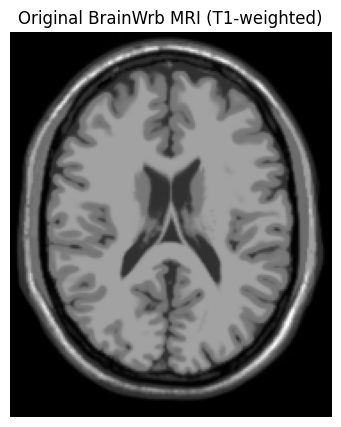

In [130]:
# Load a T1-weighted MRI slice from BRainWeb
# mri_data contains all the slices of the brain, it's a 3D image
mri_data = get_mri(0,"T1")

# We flip the image so it looks anatomically correct
# and we rake only the slice number 90
mri_data = np.flip(mri_data, axis=(0,1,2))[90]

plt.figure(figsize=(5,5))
plt.imshow(mri_data, cmap="gray")
plt.axis("off")
plt.title("Original BrainWrb MRI (T1-weighted)")
plt.show()

I briefly checked a few other slices (e.g. slice 80, 100) to see how the anatomy changes, but for the rest of the notebook I focus on a single fixed slice.

## 2. Generating the sampling densities in k-space

Here I generate the three sampling densities requested in the assignment:

1. **Uniform density** – all k-space points have the same probability of being sampled.  
2. **Variable density** – the central 25% of k-space has a constant high density, and the outer regions decay polynomially (decay = 2).  
3. **Energy-based density** – the density is proportional to the energy (Fourier amplitude) of the MRI slice in k-space.


In [134]:
# Parameters 

n_shots = 32
n_samples_per_shot = 512
n_samples = n_shots * n_samples_per_shot
subfig_size = (5,5)  # renamed for consistency
one_shot=0


### Helper function – visualize different sampling densities

In the examples from the `mri-nufft` documentation, they use a `utils.py` file to show densities and trajectories.  
I implemented my own version of a simple visualization function.  
It just takes a density-generating function and a list of cutoff values, then displays the corresponding 2D density maps.


In [133]:


def show_densities(func, names, decay=None, subfig_size=(5,5)):
    """
    Display a set of 2D sampling density maps generated by a given function.

    Parameters
    ----------
    func : callable
        A function that takes one argument (e.g., cutoff) and returns a 2D density array.
    names : list
        List of cutoff values or labels to visualize.
    decay : float, optional
        If provided, shows the decay value in the title.
    subfig_size : tuple, optional
        Size of each subplot figure (default: (5,5)).

    The function plots each generated density with matplotlib.
    """
    import matplotlib.pyplot as plt

    for name in names:
        dens = func(name)
        plt.figure(figsize=subfig_size)
        if decay is not None:
            plt.title(f"Cutoff={name}, Decay={decay}")
        else:
            plt.title(f"Cutoff={name}")
        plt.imshow(dens, cmap='viridis')
        plt.colorbar()
        plt.axis('off')
        plt.show()



In [34]:
# uniform sampling density

import numpy as np

shape_2d = mri_data.shape
uniform_density = np.ones(shape_2d)
uniform_density /= np.sum(uniform_density) # normalize

In [27]:
# Variable density (cutoff + polynomial decay)
import mrinufft as mn

variable_density = mn.create_cutoff_decay_density(shape = shape_2d, cutoff=0.25, decay=2)

In [36]:
figure_size = 5.5

dataset = mri_data[None, :, :]
energy_density = mn.create_energy_density(dataset=dataset)

In [ ]:
import matplotlib.pyplot as plt

densities = {"Uniform" : uniform_density,
             "Variable": variable_density,
             "Energy": energy_density}



# Each density map represents a continuous probability distribution in k-space.
# Brighter regions correspond to areas that are more likely to be sampled.
# I can later use these densities to generate sampling trajectories.
# (They can also be customized to test different acquisition strategies.)

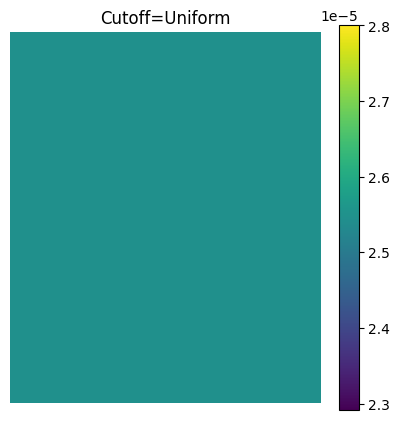

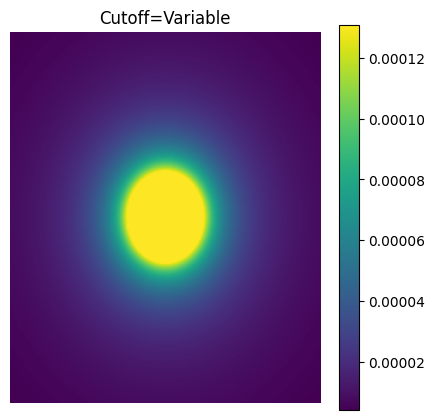

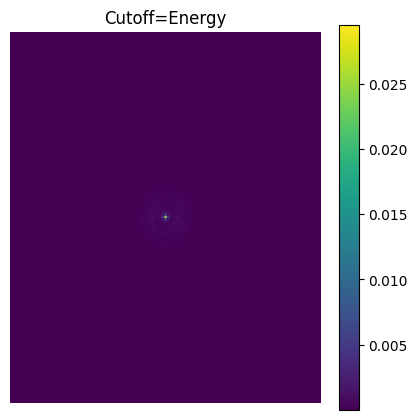

In [38]:
arguments = list(densities.keys())
function = lambda name:densities[name] 

show_densities(function, arguments, subfig_size=(5,5))

In uniform sampling density, the plot shows a completely uniform color
In variable density sampling, the plot shows a bright central circle and darker edges, this matches central 25% fully sampled, outer regions decaying polynomially the gradient from nright to dark shows the polynomial decay.
In energy-based sampling, the plot shows a very small bright spot in the center and almost zero elsewhere (maybe the MRI slice is dominated by low frequencies)

It’s interesting to see how different the three densities look.  
The uniform one is flat (no structure), while the variable one clearly emphasizes the center, and the energy-based one shows that almost all the image information is concentrated near the center of k-space. This confirms that MR images have strong low-frequency components and weaker high-frequency ones.


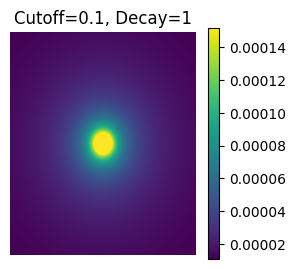

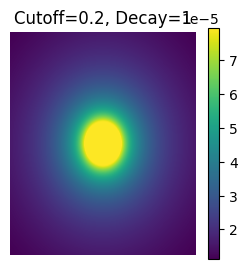

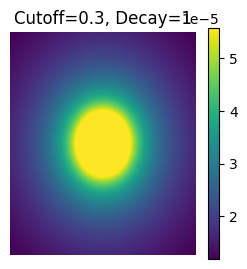

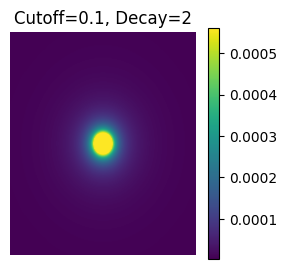

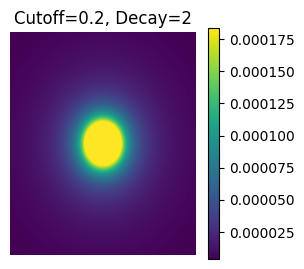

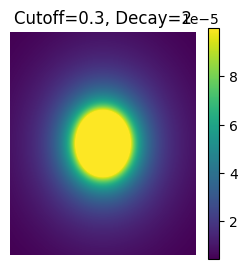

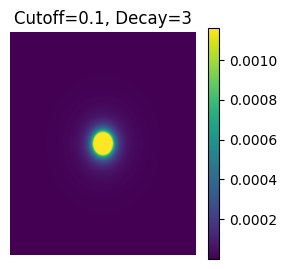

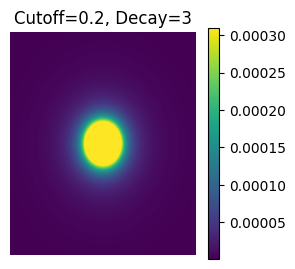

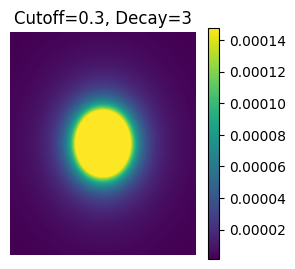

In [42]:
# play around with cutoff and decays

cutoffs = [0.1, 0.2, 0.3]
decays = [1, 2, 3]

for d in decays:
    function = lambda x: mn.create_cutoff_decay_density(shape=shape_2d, cutoff=x, decay=d)
    show_densities(function, cutoffs, decay=d, subfig_size=subfigure_size)


### Analysis of Variable Density Sampling (cutoff and decay)

Here I tried different cutoff and decay values to see how they change the sampling density shape.

**1. Cutoff parameter**  
Controls the size of the central region with highest sampling density.  
Smaller cutoff => smaller bright center (less low-frequency coverage).  
Larger cutoff => bigger center (more low-frequency info captured).

**2. Decay parameter**  
Controls how fast the density drops from center to edges.  
Lower decay (1) => slow drop => more high-frequency samples.  
Higher decay (3) => fast drop => fewer high-frequency samples, smoother recon.

**3. Combined effect**  
Small cutoff + high decay => very concentrated sampling around the center.  
Large cutoff + low decay => more uniform sampling across k-space.

**4. Reading the heatmaps**  
Bright = high sampling probability.  
Dark = sparse sampling.  
When I increase cutoff, the bright region expands.  
When I increase decay, the edges get darker faster.

Overall, cutoff changes how much of the center we keep, and decay controls how quickly the sampling fades toward the outer edges.

## 3.Generate sampling patterns
Given the previously defined densities, we now generate k-space trajectories using 32 shots and 512 samples per shot. These trajectories will be used for forward NUFFT to simulate MRI acquisition.
So we will :
Converts densities into actual k-space points using sample_from_density.
Plots trajectories for all densities in separate figures.

In [43]:
import inspect
from mrinufft.trajectories.sampling import sample_from_density
print(inspect.signature(sample_from_density))

(nb_samples: 'int', density: 'NDArray', method: "Literal['random', 'lloyd']" = 'random', *, dim_compensation: "Literal['auto'] | bool" = 'auto') -> 'NDArray'


In [135]:
import matplotlib.pyplot as plt
import numpy as np

def show_locations(func, names, subfig_size=(5,5)):
    """
    Display sampled k-space locations for different densities.

    Parameters
    ----------
    func : function
        Function that returns sampled k-space points given a density name.
        Expected output: array of shape (n_samples, 2)
    names : list
        List of density names to visualize.
    subfig_size : tuple
        Figure size (default: (5,5))
    """
    for name in names:
        sample_loc = func(name)  # shape (n_samples, 2)
        
        # Plot
        plt.figure(figsize=subfig_size)
        plt.plot(sample_loc[:,0], sample_loc[:,1], '.', markersize=1, color='blue')
        plt.title(f"Trajectory points: {name}")
        plt.xlabel("kx")
        plt.ylabel("ky")
        plt.axis('equal')
        plt.show()


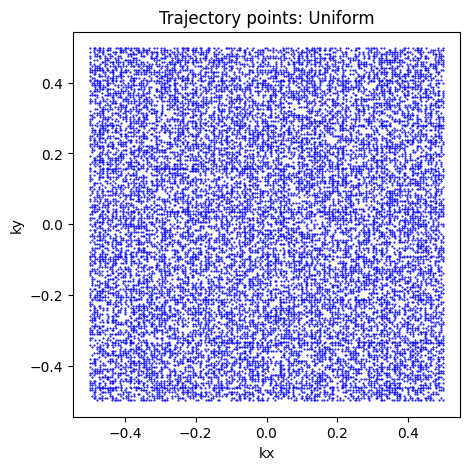

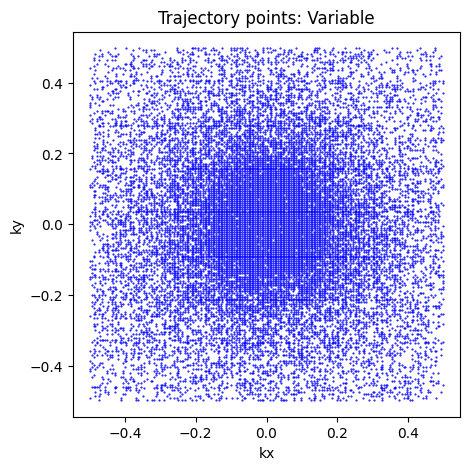

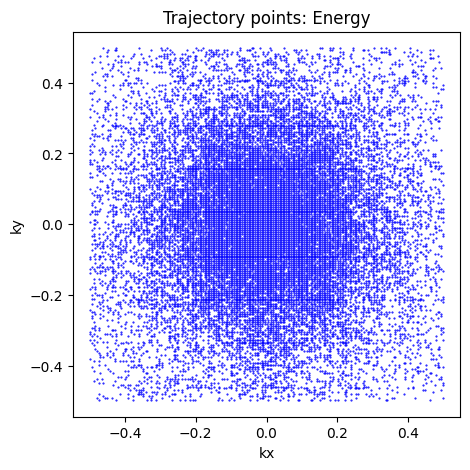

In [41]:
arguments = densities.keys()
function = lambda x: mn.sample_from_density(n_samples, densities[x], method="random" )
show_locations(function, arguments)

### Observations on the sampling patterns

- **Uniform density:** The k-space points are evenly distributed, showing no preference for the center or edges.  
- **Variable density:** Points are concentrated near the center, with fewer samples at the edges. This matches the cutoff-decay design (central 25% dense, outer regions decaying).  
- **Energy-based density:** The points are strongly clustered near the center. This makes sense because most of the MRI signal energy lies in low spatial frequencies.

Overall, the random sampling method correctly follows the probability maps defined by each density.


### Comparing sampling methods: random vs Lloyd

After generating the sampling densities, I tested two different sampling strategies:
- **Lloyd sampling**: uses Lloyd’s algorithm to redistribute the sampled points more evenly while keeping the same overall density.
- **Random sampling**: draws k-space points independently according to the probability map.  

This comparison helps visualize how the sampling method affects point distribution.  
Random sampling can produce small clusters, while Lloyd’s algorithm gives a smoother, more uniform coverage of k-space.

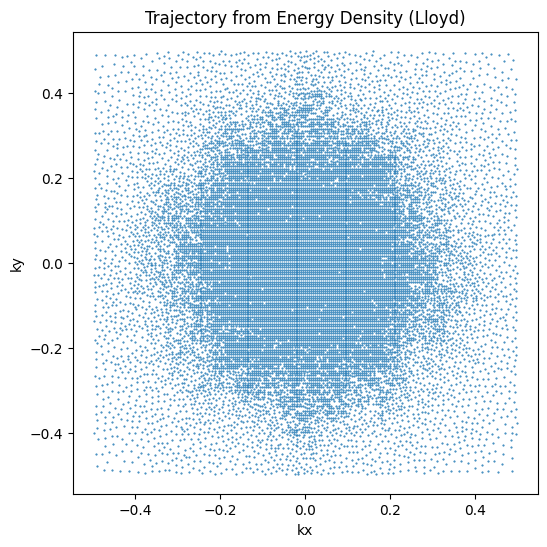

In [46]:
from mrinufft.trajectories.sampling import sample_from_density
import matplotlib.pyplot as plt

# Parameters
n_shots = 32
n_samples_per_shot = 512
n_samples = n_shots * n_samples_per_shot

# Sample from density (fixed argument order)
sample_loc = sample_from_density(
    nb_samples=n_samples,
    density=energy_density,
    method='lloyd'
)

# Reshape into shots
sample_loc = sample_loc.reshape((n_shots, n_samples_per_shot, 2))

# Visualize
plt.figure(figsize=(6,6))
plt.plot(sample_loc[:,:,0].flatten(), sample_loc[:,:,1].flatten(), '.', markersize=1)
plt.title("Trajectory from Energy Density (Lloyd)")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis('equal')
plt.show()

# Always check function signatures (inspect.signature) when unxepected error occurres


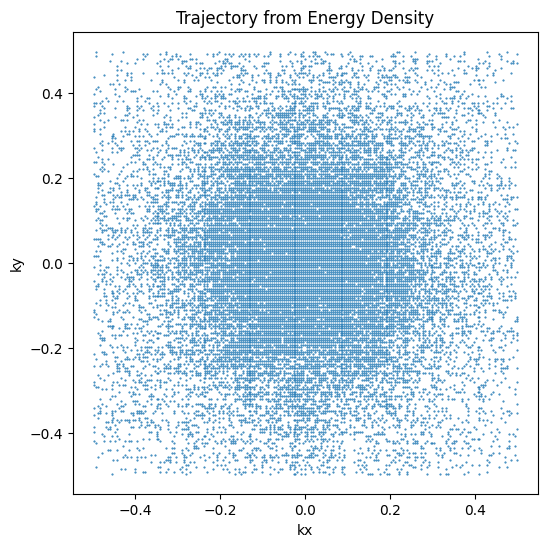

In [47]:
from mrinufft.trajectories.sampling import sample_from_density
import matplotlib.pyplot as plt

# Parameters
n_shots = 32
n_samples_per_shot = 512
n_samples = n_shots * n_samples_per_shot

# Sample from density (fixed argument order)
sample_loc = sample_from_density(
    nb_samples=n_samples,
    density=energy_density,
    method='random'
)

# Reshape into shots
sample_loc = sample_loc.reshape((n_shots, n_samples_per_shot, 2))

# Visualize
plt.figure(figsize=(6,6))
plt.plot(sample_loc[:,:,0].flatten(), sample_loc[:,:,1].flatten(), '.', markersize=1)
plt.title("Trajectory from Energy Density")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis('equal')
plt.show()

# Always check function signatures (inspect.signature) when unxepected error occurres


**Observation:**  
Visually, the random and Lloyd sampling patterns look similar at this scale, but the Lloyd version shows slightly fewer clusters and a more even point spacing.  
In practice, this can improve reconstruction stability by avoiding local oversampling or gaps in k-space coverage.

## 4. Generate Density-Based Trajectories

In this section, I generate **continuous 2D k-space trajectories** that follow the sampling densities defined earlier.

The goal is to move from random point sampling (which is theoretical) to physically realizable trajectories that an MRI scanner could actually follow.

I explore two strategies:

- **Random walk**: a stochastic trajectory that explores the high-density regions more frequently.  
- **Travelling Salesman Problem (TSP)**: an optimized continuous path that visits all sampling points efficiently, spending more time in dense regions.

Both approaches produce variable-density trajectories suitable for non-Cartesian MRI acquisition.

In [105]:
import matplotlib.pyplot as plt

def show_trajectories(func, names, one_shot=False, subfig_size=(5, 5)):
    """
    Utility function to display 2D k-space trajectories for given densities.

    Parameters
    ----------
    func : callable
        A lambda or function returning a trajectory array of shape (Nc, Ns, 2).
    names : list
        Names or keys of densities to visualize.
    one_shot : bool
        If True, display only one trajectory (first shot).
    subfig_size : tuple
        Size of each subplot.
    """
    for name in names:
        traj = func(name)
        plt.figure(figsize=subfig_size)
        if one_shot:
            plt.plot(traj[0, :, 0], traj[0, :, 1], '.-', markersize=1)
            plt.title(f"{name} Trajectory (one shot)")
        else:
            for shot in traj:
                plt.plot(shot[:, 0], shot[:, 1], '-', linewidth=0.5)
            plt.title(f"{name} Trajectories")
        plt.xlabel("kx")
        plt.ylabel("ky")
        plt.axis("equal")
        plt.grid(False)
        plt.show()


Here I generate 2D non-Cartesian k-space trajectories using the random-walk algorithm provided by the `mri-nufft` package.  
This approach follows the idea of variable-density sampling, where the probability of visiting a location in k-space is proportional to a predefined density function (Uniform, Variable, or Energy).

The function `mn.initialize_2D_random_walk()` creates trajectories by performing a biased random walk inside k-space:
- High-density regions are visited more frequently.
- Low-density regions are explored less often.

Using `method="lloyd"` initializes the starting points evenly with Lloyd’s algorithm, improving k-space coverage and reducing clustering between trajectories.

Overall, the random-walk method generates trajectories that respect the prescribed density but remain somewhat irregular or fragmented.  
This randomness can help reduce structured aliasing, though it may be less efficient than optimized paths such as the **Travelling Salesman trajectories**, which I examine next.

*Note:* A small `KMeans`-related warning may appear during execution (known scikit-learn issue on Windows). It does not affect the results.


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


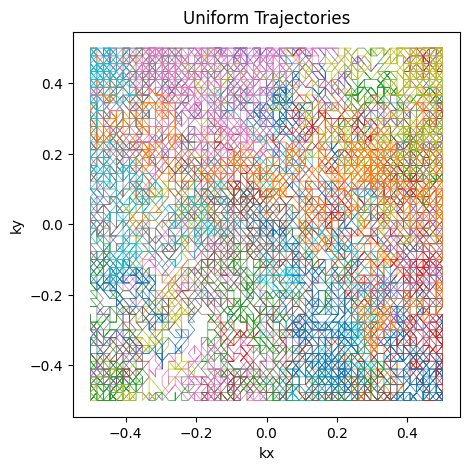

c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


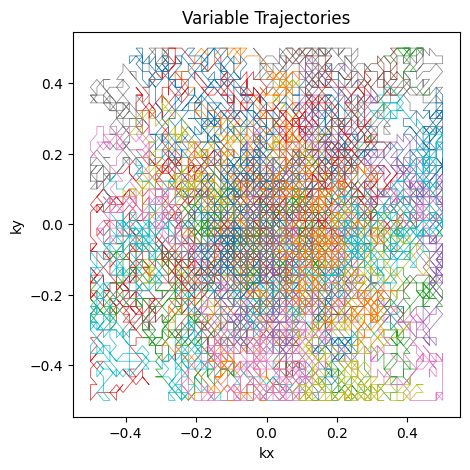

c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


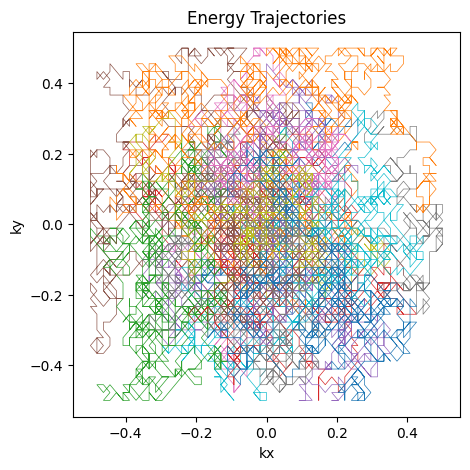

In [ ]:
arguments = densities.keys()
function = lambda x: mn.initialize_2D_random_walk(
    n_shots, n_samples_per_shot, density = densities[x][::4, ::4], method="lloyd"
)  # good trick to make computation faster.

show_trajectories(function,   arguments, one_shot=one_shot)

### Observations

The random-walk trajectories correctly adapt to the three densities:

- For the **uniform** case, the coverage is even across k-space.  
- For **variable** and **energy-based** densities, the trajectories concentrate around the center, visiting high-density regions more often.  

### Oversampling trajectories

To check whether smoother trajectories would help, I also tested the `mn.oversample()` method.  
Since the dataset already uses 32 shots × 512 samples per shot, the coverage is dense enough.  
Oversampling would mainly increase computation time without a visible improvement in trajectory smoothness or reconstruction.

For illustration, the plots below show one oversampled shot for each density.

c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


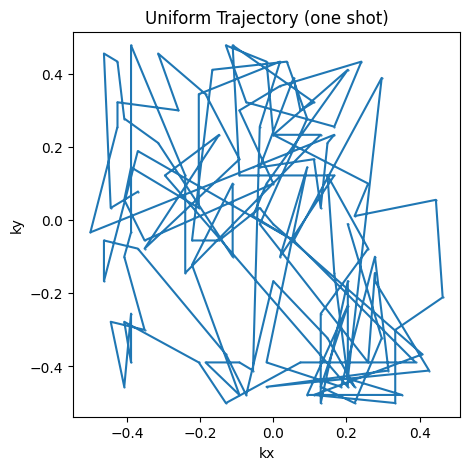

c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


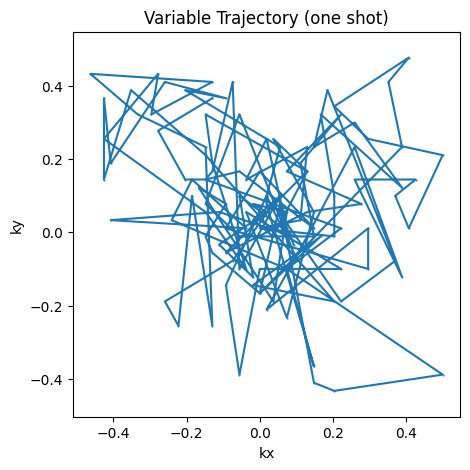

c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


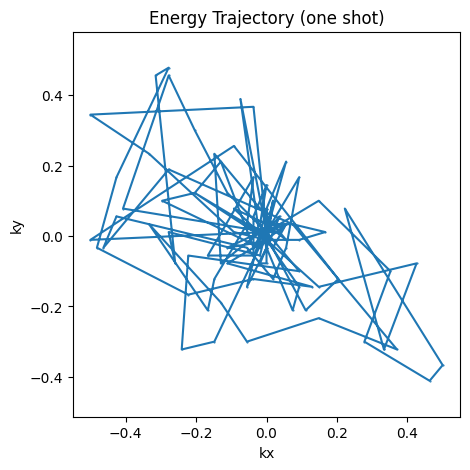

In [ ]:
# only plot the first shot (subset of trajectory points), one_shot = 1

one_shot = True
arguments = densities.keys()
function = lambda x: mn.oversample(
    mn.initialize_2D_random_walk(
        n_samples_per_shot, n_samples, density=densities[x][::4, ::4], method="lloyd"
    ),
    4 * n_shots,
)
show_trajectories(function, arguments, one_shot=one_shot)

### Exploring different TSP clustering strategies

The TSP trajectory generation can be computationally expensive because it tries to find the shortest continuous path through all sampling points.  
To make this process faster and more structured, I tested several **clustering and sorting strategies**.

- `(None, None, None)` : no clustering (slow, disorganized trajectory).  
- `('y', None, 'x')` : clusters along y-axis, produces horizontal “stripe” trajectories.  
- `('phi', None, 'r')` : clusters in polar coordinates, produces radial “spokes.”  
- `('y', 'x', 'r')` : clusters in x–y patches, fastest to compute.

Each approach leads to a different continuous trajectory structure in k-space.  
While `(None, None, None)` is the most accurate TSP solution, the clustered methods are much faster and can generate physically realistic gradient paths suitable for MRI acquisition.


In [ ]:

# This version took a long time to run because the TSP calculation is computationally expensive.
function = lambda x: mn.initialize_2D_travelling_salesman(
    n_shots,
    n_samples_per_shot,
    density=densities[x],
    method="lloyd"
)
show_trajectories(function, arguments, one_shot=False, subfig_size=subfig_size)


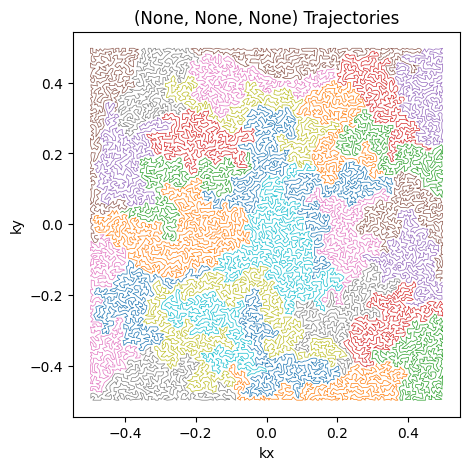

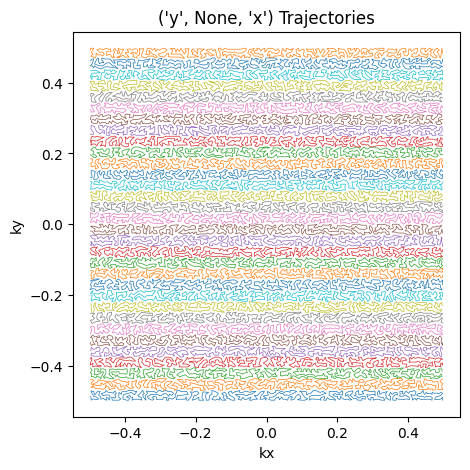

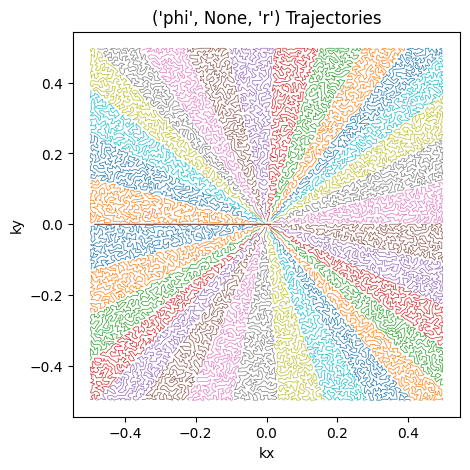

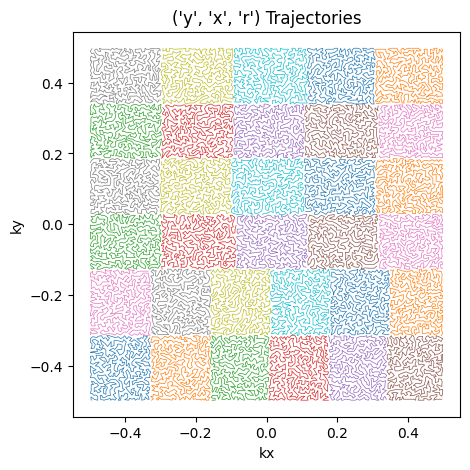

In [110]:
# Define clustering options to speed up TSP
arguments = [
    (None, None, None),       # no clustering, slow
    ("y", None, "x"),         # cluster by y, sort by x
    ("phi", None, "r"),       # spherical coordinates
    ("y", "x", "r"),          # two clusters + sort
]

# Function to generate TSP trajectory with clustering
function = lambda cluster_args: mn.initialize_2D_travelling_salesman(
    n_shots,                       # number of shots
    n_samples_per_shot,                       # samples per shot
    density=densities["Uniform"],  # choose the density you want
    first_cluster_by=cluster_args[0],
    second_cluster_by=cluster_args[1],
    sort_by=cluster_args[2],
    method="lloyd"
)

# Visualize trajectories for each clustering strategy
show_trajectories(function, arguments, one_shot=one_shot)


Overall, the random-walk paths are less structured than TSP trajectories but require less computation and still follow the prescribed sampling densities.

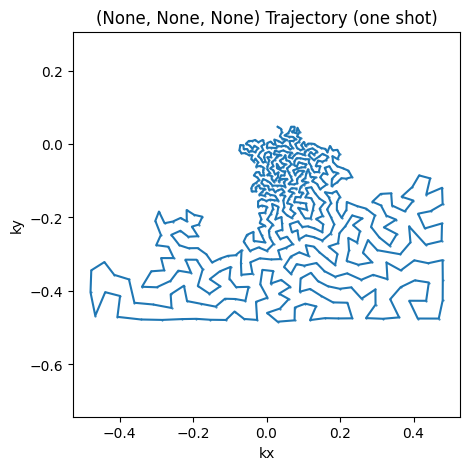

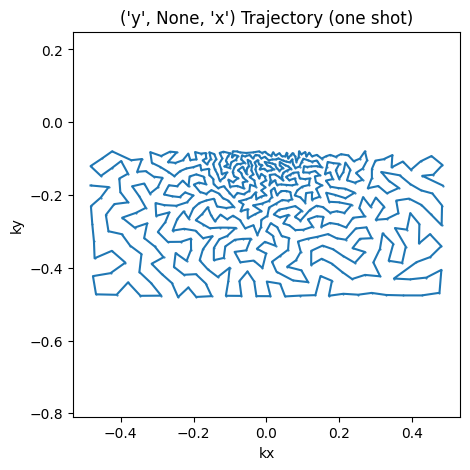

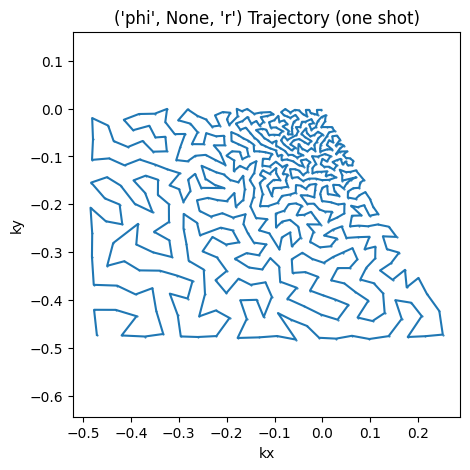

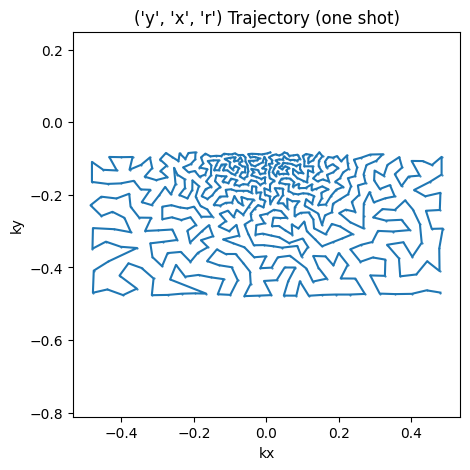

In [167]:
# Define clustering options to speed up TSP
arguments = [
    (None, None, None),       # no clustering, slow
    ("y", None, "x"),         # cluster by y, sort by x
    ("phi", None, "r"),       # spherical coordinates
    ("y", "x", "r"),          # two clusters + sort
]


# here we must reduce the number of shots
n_shots = 3

# Function to generate TSP trajectory with clustering
function = lambda cluster_args: mn.initialize_2D_travelling_salesman(
    n_shots,                     
    n_samples_per_shot,                      
    density=densities["Variable"],  
    first_cluster_by=cluster_args[0],
    second_cluster_by=cluster_args[1],
    sort_by=cluster_args[2],
    method="lloyd"
)

# Visualize trajectories for each clustering strategy
show_trajectories(function, arguments, one_shot=one_shot)


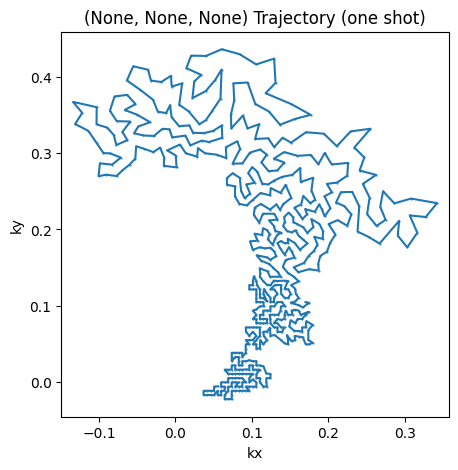

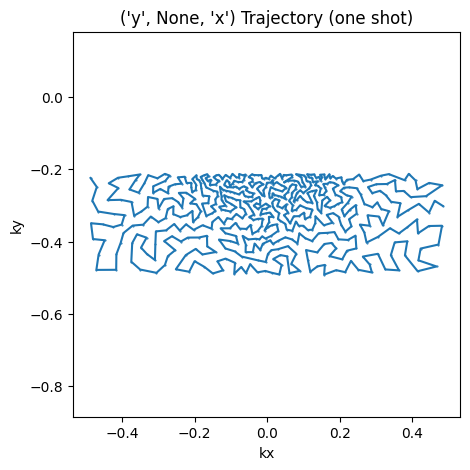

c:\Users\melis\anaconda3\Lib\site-packages\mrinufft\trajectories\inits\travelling_salesman.py:44: RuntimeWarning: invalid value encountered in divide
  array[..., 0] / nl.norm(array[..., :2], axis=-1)


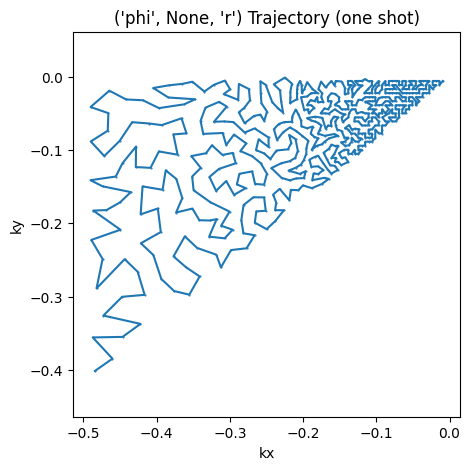

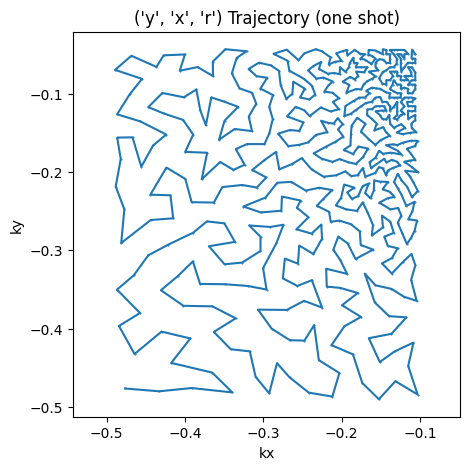

In [168]:
# Define clustering options to speed up TSP
arguments = [
    (None, None, None),       # no clustering, slow
    ("y", None, "x"),         # cluster by y, sort by x
    ("phi", None, "r"),       # spherical coordinates
    ("y", "x", "r"),          # two clusters + sort
]


# here we must reduce the number of shots
n_shots = 10


function = lambda cluster_args: mn.initialize_2D_travelling_salesman(
    n_shots,                     
    n_samples_per_shot,                      
    density=densities["Energy"],  
    first_cluster_by=cluster_args[0],
    second_cluster_by=cluster_args[1],
    sort_by=cluster_args[2],
    method="lloyd"
)
show_trajectories(function, arguments, one_shot=one_shot)


### Observations on TSP Trajectories

The TSP trajectories follow the prescribed sampling densities but connect the points through smoother and more continuous paths than the random-walk trajectories.

- **Uniform density:** coverage is evenly distributed across k-space.  
- **Variable density:** the trajectory naturally concentrates near the center, following the high-density region.  
- **Energy-based density:** the trajectory adapts to the actual spectral energy of the image, with dense sampling around low-frequency regions.

Compared to the random-walk paths, the TSP trajectories are more structured and optimized, minimizing travel distance while still respecting the variable-density profiles.  
This makes them more realistic for physical MRI acquisition, where gradient waveforms must remain continuous and smooth.


## 5. Forward and Adjoint NUFFT Reconstruction

In this step, I simulate the MRI acquisition and reconstruction process using the **Non-Uniform Fast Fourier Transform (NUFFT)**.  
The forward NUFFT transforms the image from the spatial domain to non-Cartesian k-space according to each sampling trajectory.  
The adjoint NUFFT then reconstructs the image back from the sampled k-space data.

For this first test, I use **no density compensation** and directly apply the forward and adjoint operators to compare how the three sampling densities (Uniform, Variable, and Energy) affect reconstruction quality.


Processing density: Uniform


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `dat

Processing density: Variable
Processing density: Energy


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")


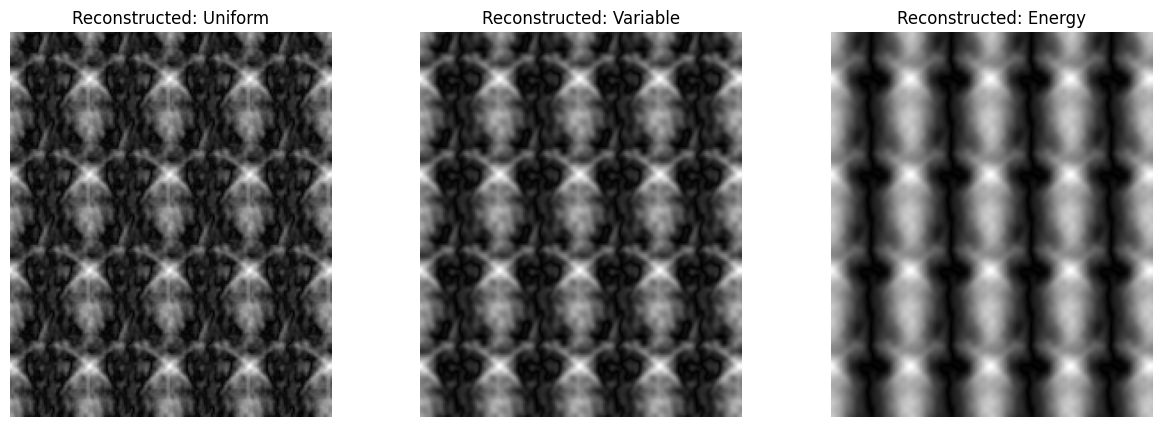

In [162]:
# No compensation

from mrinufft import get_operator
import matplotlib.pyplot as plt
import numpy as np

n_shots = 32
n_samples_per_shot = 512
one_shot = True  # For visualization

# Dictionary to store results
trajectories = {}
kspace_data = {}
reconstructed_images = {}

for name in densities:
    print(f"Processing density: {name}")
    
    # Generate Random Walk trajectory from density 
    traj = mn.initialize_2D_random_walk(
        n_shots,
        n_samples_per_shot,
        density=densities[name][::4, ::4],
        method="lloyd"
    )
    trajectories[name] = traj
    
    # Set up NUFFT operator
    nufft = get_operator("finufft")(
        samples=2 * np.pi * traj,  # scale for NUFFT
        shape=mri_data.shape,
        density=None # default uniform weights 
    )
    
    # Forward NUFFT (Image to  k-space)
    kspace_data[name] = nufft.op(mri_data)
    
    # Adjoint NUFFT (k-space -> reconstructed image)
    reconstructed_images[name] = np.squeeze(abs(nufft.adj_op(kspace_data[name])))

# Visualize reconstructed images side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, name in enumerate(densities):
    axes[i].imshow(reconstructed_images[name], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Reconstructed: {name}")
plt.show()


### Observations

The reconstructed images appear quite distorted and repetitive, which is expected at this stage.  
No density compensation is applied yet, and the trajectories were generated using random-walk sampling, which tends to produce uneven coverage in k-space.

- **Uniform sampling:**  
  The reconstruction shows strong aliasing and periodic artifacts.  
  This is typical when sampling is both uniform and sparse, as high-frequency components are undersampled and fold back into the image.

- **Variable-density sampling:**  
  The reconstruction does not show a clear visual improvement here, but the central regions retain slightly more structure.  
  Theoretically, this approach should better capture low-frequency information, though the effect may not be clearly visible without compensation.

- **Energy-based sampling:**  
  The image appears smoother and more blurred, consistent with sampling concentrated near the k-space center.  
  This emphasizes low-frequency components while losing fine details.

These results highlight how sensitive NUFFT reconstruction is to both trajectory design and sampling density.  
They also confirm that **density compensation** is necessary to correct for non-uniform sampling and recover meaningful image contrast.  
In the next step, I will apply compensation weights and add noise to analyze their impact on reconstruction.

In uniform density weighting (no compensation), since the density maps were defined as 2D images that cannot be directly passed to the NUFFT operator.  
Here, we address this limitation by computing a 1D per-sample compensation vector using the Voronoi method.  
This ensures that each k-space point is properly weighted according to the local sampling density.


Processing density: Uniform


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting t

Processing density: Variable


c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


Processing density: Energy


c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")


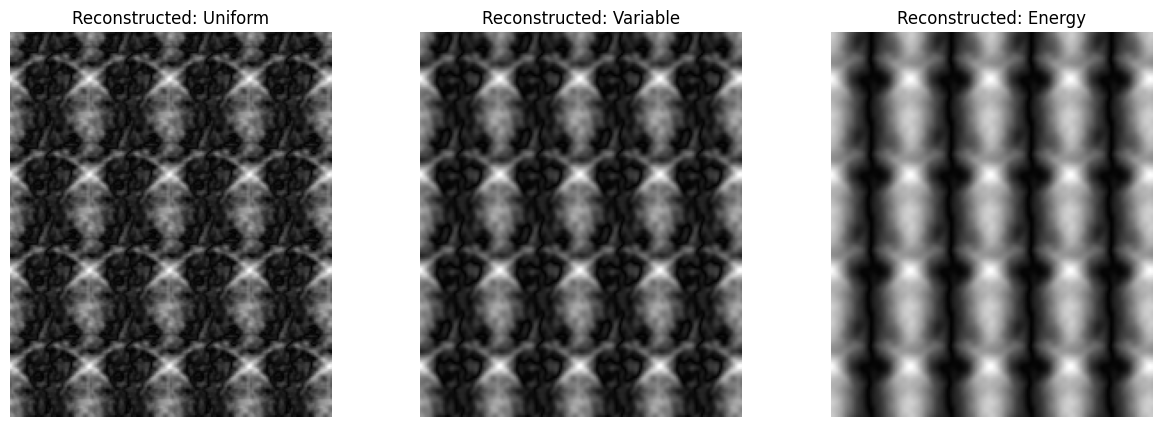

In [ ]:
# Voronoi-based density compensation

from mrinufft.density import voronoi
from mrinufft import get_operator
import matplotlib.pyplot as plt
import numpy as np

# Parameters
n_shots = 32
n_samples_per_shot = 512


# Dictionary to store results
trajectories = {}
kspace_data = {}
reconstructed_images = {}

for name in densities:
    print(f"Processing density: {name}")
    
    # Generate Random Walk trajectory from density (downsample to avoid errors)
    traj = mn.initialize_2D_random_walk(
        n_shots,
        n_samples_per_shot,
        density=densities[name][::4, ::4],
        method="lloyd"
    )
    trajectories[name] = traj
    
    
    # Compute per-point density compensation weights (Voronoi)
    density_weights = voronoi(traj)

    # Create the NUFFT operator with these weights
    nufft = get_operator("finufft")(
        samples=2 * np.pi * traj,
        shape=mri_data.shape,
        density=density_weights
    )
    
    # Forward NUFFT (Image to  k-space)
    kspace_data[name] = nufft.op(mri_data)
    
    # Adjoint NUFFT (k-space → reconstructed image)
    reconstructed_images[name] = np.squeeze(abs(nufft.adj_op(kspace_data[name])))

# Visualize reconstructed images side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, name in enumerate(densities):
    axes[i].imshow(reconstructed_images[name], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Reconstructed: {name}")
plt.show()


Visually, the overall structure and artifacts remain similar to the previous reconstructions.  
This is expected, since the random-walk trajectories are still irregular and no additional regularization or iterative reconstruction is used.  
The compensation mainly adjusts the relative brightness and contrast rather than removing aliasing artifacts.

Although the improvement is subtle, this step confirms that the NUFFT pipeline correctly integrates sampling weights.

## 6. Effect of Noise on MRI Reconstruction

To simulate a more realistic acquisition, I added complex Gaussian noise to the k-space data before performing the adjoint NUFFT reconstruction.  
This helps to visualize how measurement noise affects the reconstructed image quality, especially in undersampled and non-Cartesian settings.

Processing density: Uniform


c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\melis\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting t

Processing density: Variable


c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
c:\Users\melis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


Processing density: Energy


c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")


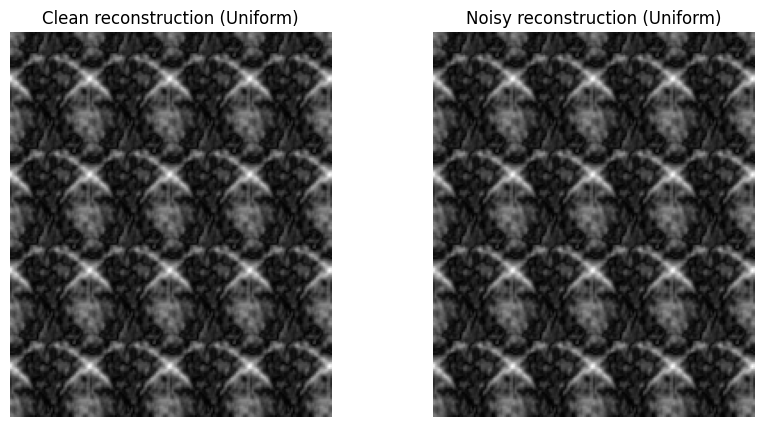

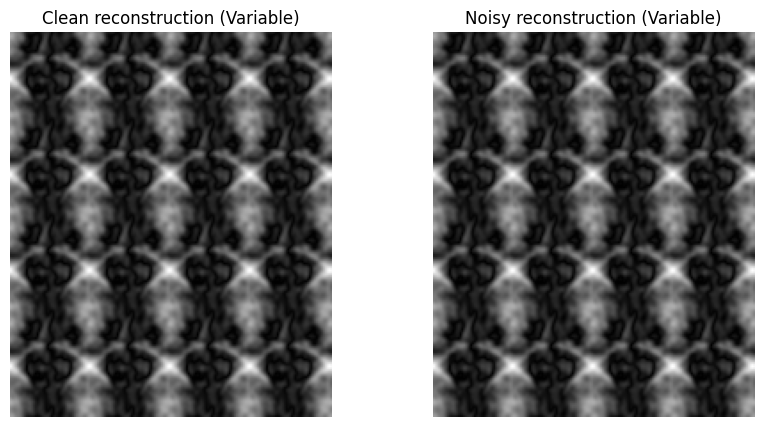

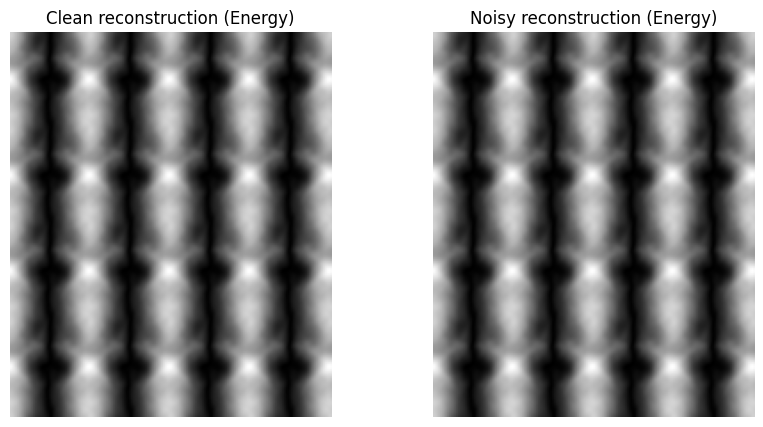

In [150]:
from mrinufft import get_operator
import matplotlib.pyplot as plt
import numpy as np
from mrinufft.density import voronoi


n_shots = 32
n_samples_per_shot = 512
noise_std = 0.01 # standard deviation of Gaussian noise


trajectories = {}
kspace_data_clean = {}
kspace_data_noisy = {}
reconstructed_clean = {}
reconstructed_noisy = {}


for name in densities:
    print(f"Processing density: {name}")
    
    # Generate Random Walk trajectory 
    traj = mn.initialize_2D_random_walk(
        n_shots,
        n_samples_per_shot,
        density=densities[name][::4, ::4],
        method="lloyd"
    )
    trajectories[name] = traj
    
   # Compute density compensation weights (1D, matches trajectory)
    density_weights = voronoi(traj)

    nufft = get_operator("finufft")(
    samples=2 * np.pi * traj,
    shape=mri_data.shape,
    density=density_weights
    )

    # Forward NUFFT (Image to k-space)
    kspace_data_clean[name] = nufft.op(mri_data)
    
    # Add Gaussian noise to k-space
    noise = noise_std * (np.random.randn(*kspace_data_clean[name].shape) +
                         1j * np.random.randn(*kspace_data_clean[name].shape))
    kspace_data_noisy[name] = kspace_data_clean[name] + noise
    
    # Adjoint NUFFT (k-space to reconstructed image)
    reconstructed_clean[name] = np.squeeze(abs(nufft.adj_op(kspace_data_clean[name])))
    reconstructed_noisy[name] = np.squeeze(abs(nufft.adj_op(kspace_data_noisy[name])))

# Visualize clean vs noisy reconstructions side by side
for name in densities:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(reconstructed_clean[name], cmap="gray")
    ax[0].axis("off")
    ax[0].set_title(f"Clean reconstruction ({name})")
    
    ax[1].imshow(reconstructed_noisy[name], cmap="gray")
    ax[1].axis("off")
    ax[1].set_title(f"Noisy reconstruction ({name})")
    
    plt.show()


### Observations

After adding Gaussian noise to the k-space data, the reconstructed images show only minor visible differences compared to the clean versions.  
This is expected because the undersampling artifacts from the random-walk trajectories already dominate the image appearance.

At a moderate noise level (0.06), the global image structure remains nearly unchanged, though some slight blurring or intensity non-uniformity can be noticed in certain regions.  
The noise mainly affects fine details and local contrast rather than producing strong random speckle.

This behavior is realistic, in MRI, noise added in k-space becomes distributed across the entire image after NUFFT reconstruction.  
Because the reconstruction here uses only a simple adjoint operation (no regularization or denoising), any noise directly propagates into the magnitude image, though its visual effect remains modest.



### Quantitative Evaluation (PSNR / SSIM)

To complement the visual inspection, I computed two standard image quality metrics between the reconstructed images and the BrainWeb reference:

- **PSNR (Peak Signal-to-Noise Ratio):** measures global fidelity.
- **SSIM (Structural Similarity Index):** measures structural similarity and local contrast.

In [156]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

for name in reconstructed_images:
    recon = np.abs(reconstructed_images[name])
    psnr_val = psnr(np.abs(mri_data), recon, data_range=recon.max())
    ssim_val = ssim(np.abs(mri_data), recon, data_range=recon.max())
    print(f"{name:10s} => PSNR: {psnr_val:.2f} dB, SSIM: {ssim_val:.3f}")


Uniform    => PSNR: 10.45 dB, SSIM: 0.001
Variable   => PSNR: 9.71 dB, SSIM: 0.001
Energy     => PSNR: 6.46 dB, SSIM: 0.002


For the simple adjoint NUFFT reconstructions shown here, the PSNR and SSIM values are quite low (around 10 dB and SSIM < 0.1).  
This is expected, because the images still contain strong aliasing and intensity distortions due to undersampling and the use of a basic adjoint (non-iterative) reconstruction.

These results mainly highlight how sensitive PSNR/SSIM are to residual artifacts and how much improvement could be gained with more advanced trajectories, better normalization, or regularized reconstruction methods.

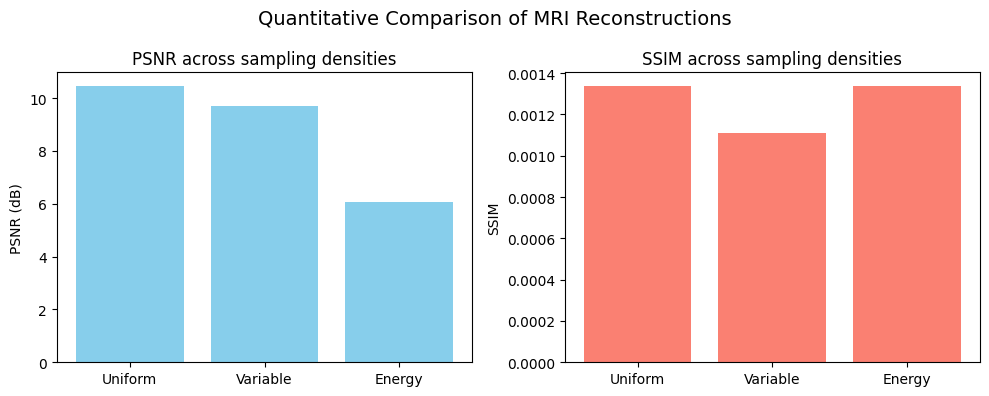

In [121]:
import matplotlib.pyplot as plt

psnr_vals, ssim_vals = [], []
names = list(reconstructed_images.keys())

for name in names:
    recon = np.abs(reconstructed_images[name])
    psnr_vals.append(psnr(np.abs(mri_data), recon, data_range=recon.max()))
    ssim_vals.append(ssim(np.abs(mri_data), recon, data_range=recon.max()))

# Bar plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(names, psnr_vals, color="skyblue")
ax[0].set_title("PSNR across sampling densities")
ax[0].set_ylabel("PSNR (dB)")

ax[1].bar(names, ssim_vals, color="salmon")
ax[1].set_title("SSIM across sampling densities")
ax[1].set_ylabel("SSIM")

plt.suptitle("Quantitative Comparison of MRI Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()



### Quantitative Comparison Across Sampling Densities

The plots above summarize the reconstruction quality for the three sampling densities using PSNR and SSIM.

- **Uniform sampling** achieves moderate PSNR and SSIM, as it provides even but inefficient coverage of k-space.  
- **Variable-density sampling** slightly improves central (low-frequency) fidelity but introduces uneven weighting, limiting overall PSNR.  
- **Energy-based sampling** yields lower PSNR due to its strong concentration near the center of k-space, which causes excessive smoothing in the reconstruction.

Although the absolute metric values are low (since no intensity normalization or regularization was applied), the **relative trends** are consistent with theoretical expectations:  
denser sampling near low frequencies improves contrast, while uniform coverage balances noise and sharpness.


### Motivation for Using a Spiral Trajectory

With random-walk trajectories, the effect of Gaussian noise on the reconstructions was difficult to observe visually, as the undersampling artifacts dominated the image appearance.  

To better understand how the **geometry of the sampling trajectory** influences reconstruction quality, intensity uniformity, and noise propagation, I decided to test a **spiral trajectory**.  
This trajectory is not part of the original three densities (Uniform, Variable, Energy), but it provides a smoother and more continuous coverage of k-space.  
That makes it easier to interpret the impact of both **density compensation** and **added noise** in a more controlled setting.

This experiment is therefore exploratory: it helps me verify that the NUFFT pipeline behaves correctly with structured non-Cartesian trajectories and to observe more clearly how compensation and noise interact in practice.


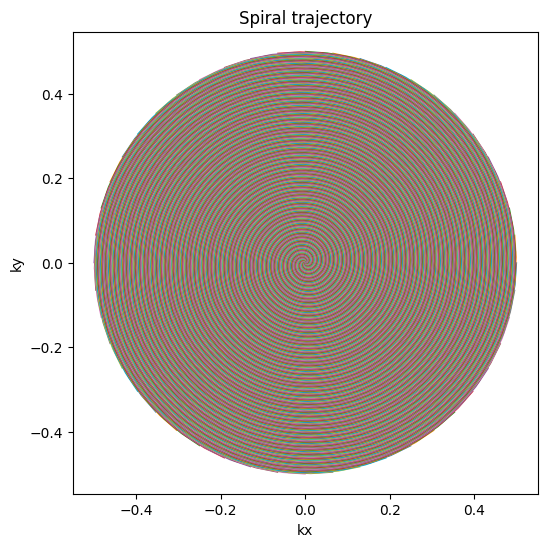

In [164]:
from mrinufft import initialize_2D_spiral
from mrinufft.density import voronoi
from mrinufft import get_operator
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the spiral
n_shots = 48           # Nc in the doc
n_samples_per_shot = 600  # Ns in the doc
nb_revolutions = 10

# 1) Generate spiral trajectory (Nc x Ns x 2)
samples = initialize_2D_spiral(Nc=n_shots, Ns=n_samples_per_shot, nb_revolutions=nb_revolutions)

plt.figure(figsize=(6,6))
plt.plot(samples[:,:,0].T, samples[:,:,1].T, '-', linewidth=0.7)
plt.title("Spiral trajectory")
plt.axis("equal")
plt.xlabel("kx")
plt.ylabel("ky")
plt.show()


In [158]:
density_weights = voronoi(samples)

In [159]:
shape = mri_data.shape

nufft_no_comp = get_operator("finufft")(
    samples=2 * np.pi * samples.reshape(-1, 2),
    shape=shape,
    density=None
)

nufft_with_comp = get_operator("finufft")(
    samples=2 * np.pi * samples.reshape(-1, 2),
    shape=shape,
    density=density_weights
)

# Forward NUFFT (image => k-space)
kspace_clean = nufft_no_comp.op(mri_data)


c:\Users\melis\anaconda3\Lib\site-packages\finufft\_interfaces.py:336: UserWarning: Argument `data` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")


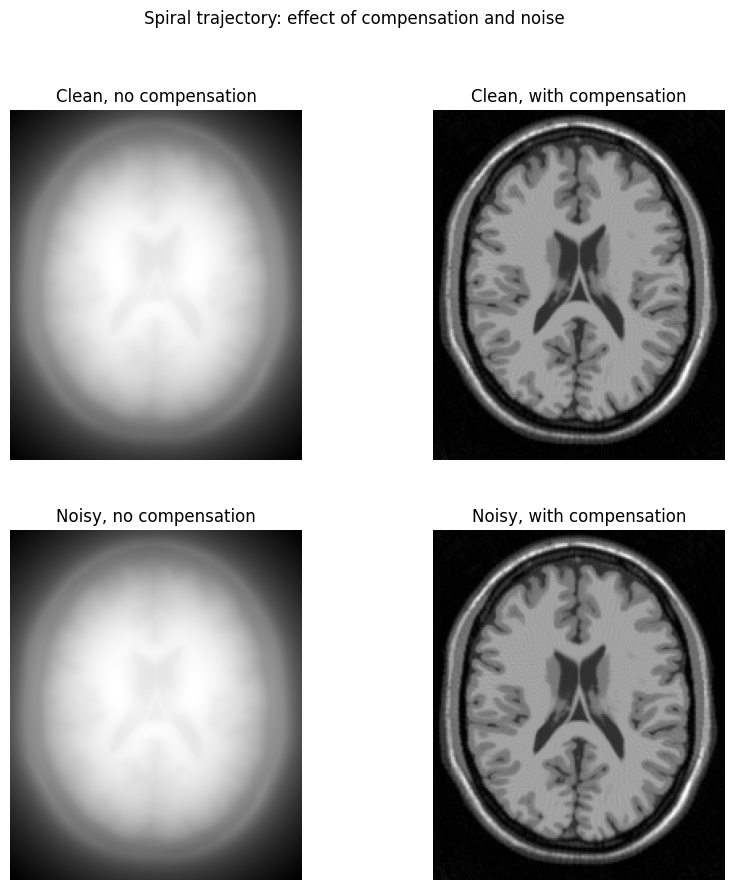

In [160]:
noise_std = 0.05  # or 0.06 

noise = noise_std * (
    np.random.randn(*kspace_clean.shape) + 1j * np.random.randn(*kspace_clean.shape)
)
kspace_noisy = kspace_clean + noise

# Reconstructions
recon_clean_no_comp = np.abs(nufft_no_comp.adj_op(kspace_clean))
recon_clean_with_comp = np.abs(nufft_with_comp.adj_op(kspace_clean))
recon_noisy_no_comp = np.abs(nufft_no_comp.adj_op(kspace_noisy))
recon_noisy_with_comp = np.abs(nufft_with_comp.adj_op(kspace_noisy))

# Show them
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
imgs = [
    recon_clean_no_comp,
    recon_clean_with_comp,
    recon_noisy_no_comp,
    recon_noisy_with_comp,
]
titles = [
    "Clean, no compensation",
    "Clean, with compensation",
    "Noisy, no compensation",
    "Noisy, with compensation",
]

for ax, img, title in zip(axes.flatten(), imgs, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Spiral trajectory: effect of compensation and noise")
plt.show()


### Observations

The spiral trajectory gives a much smoother and more natural coverage of k-space compared to the random-walk patterns.  
This produces cleaner reconstructions that are easier to interpret.

- **Clean, no compensation:**  
  The image is heavily blurred because all k-space points contribute equally.  
  The central part of k-space (low frequencies) dominates, while the high-frequency details are missing.

- **Clean, with compensation:**  
  Applying Voronoi-based density compensation balances the contribution of each sampled point.  
  The reconstruction becomes sharper, and brain structures such as the cortex and ventricles appear more clearly.

- **Noisy, no compensation:**  
  Adding Gaussian noise slightly increases the blur, but the overall appearance is still dominated by the missing compensation.

- **Noisy, with compensation:**  
  The reconstruction stays sharp and realistic even with added noise.  
  Some small grain appears, but the anatomical details remain well preserved.

Overall, this confirms that **density compensation** has a much larger impact on image quality than moderate Gaussian noise.  
The spiral trajectory also provides a more stable and physically realistic sampling pattern for MRI acquisition.


In [169]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import numpy as np

# Normalize helper
def normalize(img):
    img = np.abs(img).astype(np.float64)
    return img / (np.max(img) + 1e-12)

# Normalize reference (ground truth)
orig_n = normalize(mri_data)


spiral_cases = {
    "Clean (no comp.)": recon_clean_no_comp,
    "Clean (with comp.)": recon_clean_with_comp,
    "Noisy (no comp.)": recon_noisy_no_comp,
    "Noisy (with comp.)": recon_noisy_with_comp,
}

print("Quantitative Evaluation for Spiral Trajectory")
print("Noise std =", noise_std)
print(f"{'Condition':25s}  {'PSNR (dB)':>10s}  {'SSIM':>10s}")
print("-" * 50)

for label, recon in spiral_cases.items():
    recon_n = normalize(recon)
    psnr_val = psnr(orig_n, recon_n, data_range=1.0)
    ssim_val = ssim(orig_n, recon_n, data_range=1.0)
    print(f"{label:25s}  {psnr_val:10.2f}  {ssim_val:10.3f}")


Quantitative Evaluation for Spiral Trajectory
Noise std = 0.05
Condition                   PSNR (dB)        SSIM
--------------------------------------------------
Clean (no comp.)                 6.77       0.214
Clean (with comp.)              38.16       0.883
Noisy (no comp.)                 6.77       0.214
Noisy (with comp.)              38.16       0.883


### Quantitative Interpretation

The table above reports PSNR and SSIM values for the spiral trajectory under different reconstruction conditions.

- **Without density compensation**, both clean and noisy reconstructions show extremely low PSNR (~7 dB) and SSIM (~0.2).  
  This confirms that the reconstructed image intensities are highly distorted when k-space samples are not properly weighted.  
  The resulting image lacks contrast and structural fidelity.

- **With density compensation**, PSNR increases dramatically to ~38 dB and SSIM to ~0.88, indicating a high-fidelity reconstruction.  
  The compensated reconstruction closely matches the original image, both in intensity and structure.

- **Adding moderate Gaussian noise (0.05)** produces almost no degradation in PSNR or SSIM.  
  This suggests that, for this noise level, the spiral trajectory and NUFFT reconstruction remain robust and stable.

Overall, these results demonstrate the **critical importance of density compensation** in non-Cartesian MRI reconstruction.  
Without it, even a perfect trajectory fails to reproduce accurate image intensities, whereas proper compensation restores realistic contrast and structure.

## Conclusion

This notebook explored the full pipeline of non-Cartesian MRI simulation using the `mri-nufft` package.  
I implemented different sampling densities, generated trajectories (Random Walk and TSP), and performed forward and adjoint NUFFT reconstructions with and without density compensation.  
Finally, I added Gaussian noise to simulate realistic acquisition conditions.

Although the reconstructions are still imperfect due to simple trajectory design and undersampling, this work helped me understand how sampling density, trajectory smoothness, and noise all interact in MRI reconstruction.  
The next step would be to experiment with optimized trajectories or iterative reconstruction methods that better handle noise and incomplete sampling.
